<a href="https://colab.research.google.com/github/Pinkraaaa/Lab_3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running on: cuda



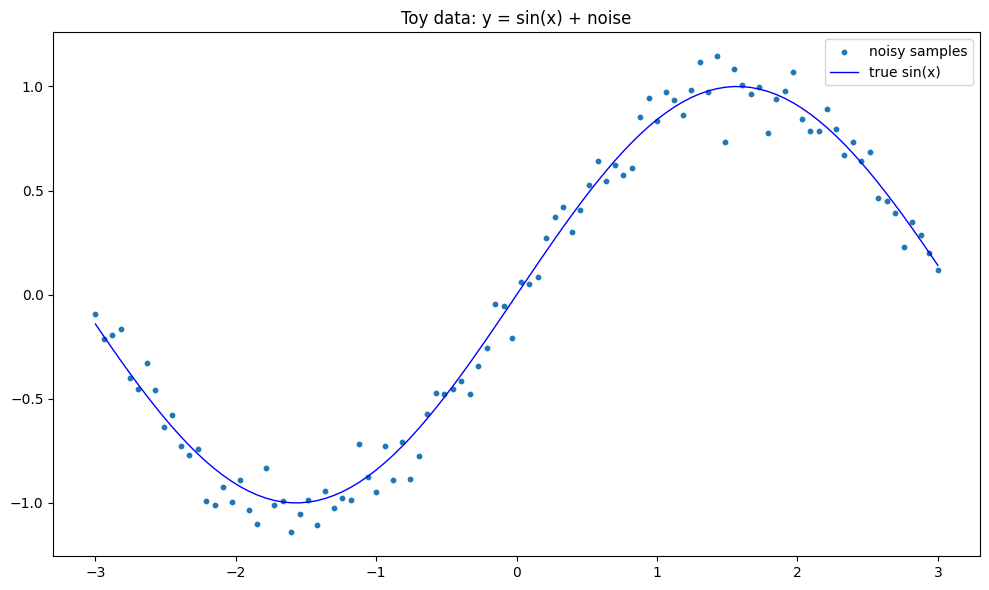


Final params: w = 0.34, b = -0.01, final loss = 0.20



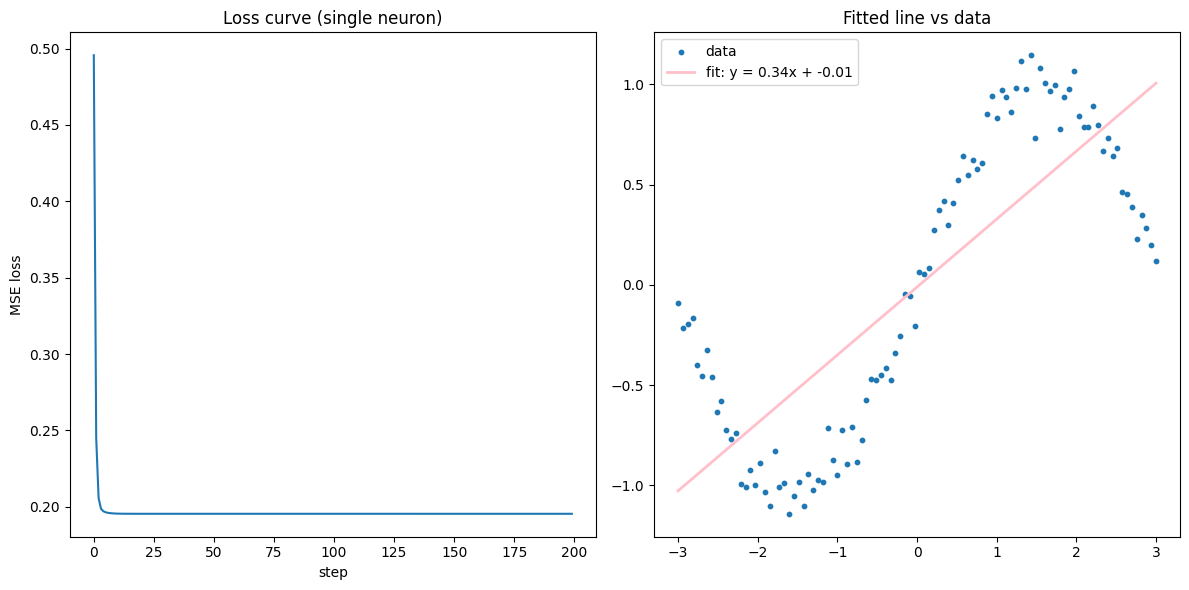

In [ ]:
#PART 0 AND 1.1
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)
print()


#PART 1.1
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

np.random.seed(RANDOM_STATE)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size = x.shape)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s = 10, label = "noisy samples")
plt.plot(x, np.sin(x), color = "blue", lw = 1, label = "true sin(x)")
plt.title("Toy data: y = sin(x) + noise")
plt.legend()
plt.tight_layout()
plt.show()


# TODO: Initialise w and b to small random values.

rng = np.random.default_rng(RANDOM_STATE)
w = rng.normal(0, 0.1)
b = rng.normal(0, 0.1)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps
lr = 0.1
n_steps = 200
losses = []

for step in range(n_steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)          #MSE
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)         #dLoss/dw
    db = np.mean(2 * (y_hat - y))             #dLoss/db

    w -= lr * dw
    b -= lr * db

print()
print(f"Final params: w = {w:.2f}, b = {b:.2f}, final loss = {losses[-1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize = (12, 6))
axes[0].plot(losses)
axes[0].set_title("Loss curve (single neuron)")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
print()



#(b) the data with the fitted line on top.
axes[1].scatter(x, y, s = 10, label = "data")
axes[1].plot(x, w * x + b, color = "pink", lw = 2, label = f"fit: y = {w:.2f}x + {b:.2f}")
axes[1].set_title("Fitted line vs data")
axes[1].legend()
plt.tight_layout()
plt.show()




PART 1.2: HIDDEN LAYERS AND ACTIVATION: WHY DEPTHS HELPS

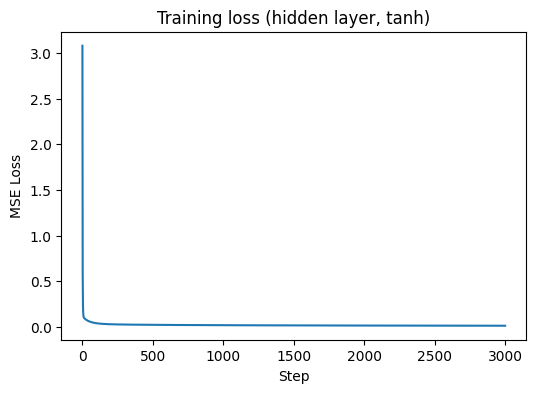

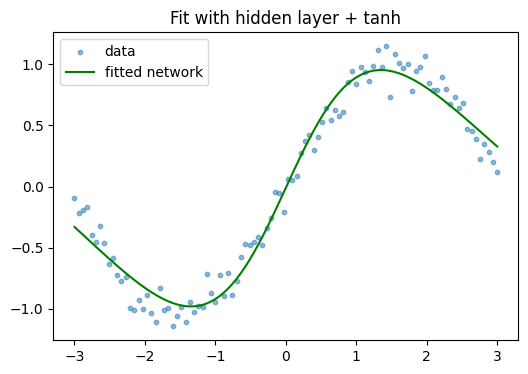

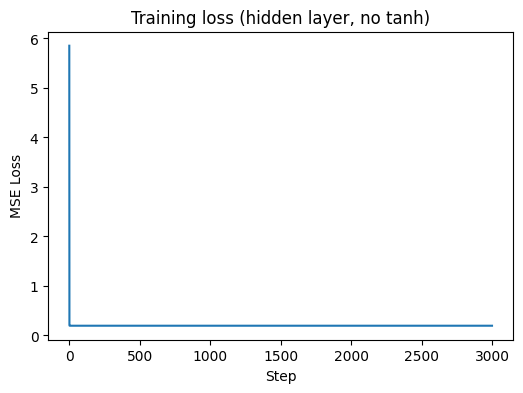

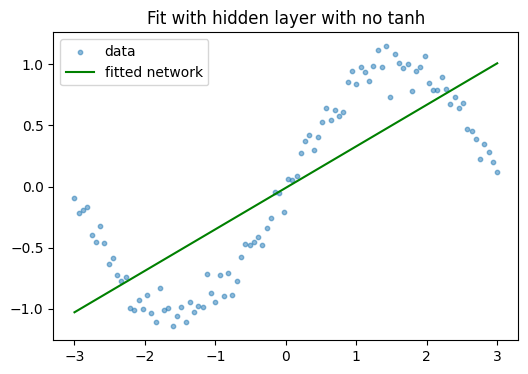

In [ ]:
#PART 1.2
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

x_col = x.reshape(-1, 1)   # (100, 1) so matrix multiply works
y_col = y.reshape(-1, 1)   # (100, 1)

lr = 0.05
steps = 3000
losses = []


# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

for step in range(steps):
    # ---- forward pass ----
    z1 = x_col @ W1 + b1        # (100, 8)
    h = np.tanh(z1)              # (100, 8)
    y_hat = h @ W2 + b2          # (100, 1)

    loss = np.mean((y_hat - y_col) ** 2)
    losses.append(loss)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# ---- backward pass ----
    d_yhat = 2 * (y_hat - y_col) / len(y_col)   # (100, 1)
    dW2 = h.T @ d_yhat                           # (8, 1)
    db2 = d_yhat.sum(axis=0)                     # (1,)

    dh = d_yhat @ W2.T                           # (100, 8)
    dz1 = dh * (1 - np.tanh(z1) ** 2)            # (100, 8)
    dW1 = x_col.T @ dz1                          # (1, 8)
    db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2



# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

plt.figure(figsize = (6, 4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Training loss (hidden layer, tanh)")
plt.show()


plt.figure(figsize = (6, 4))
plt.scatter(x, y, s = 10, label = "data", alpha = 0.5)
plt.plot(x, y_hat, color = "green", label = "fitted network")
plt.legend()
plt.title("Fit with hidden layer + tanh")
plt.show()



#RE-RUN WITHOUT TANH
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

x_col = x.reshape(-1, 1)   # (100, 1) so matrix multiply works
y_col = y.reshape(-1, 1)   # (100, 1)

lr = 0.05
steps = 3000
losses = []


for step in range(steps):
    # ---- forward pass ----
    z1 = x_col @ W1 + b1
    h = z1                      # No tanh this time
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y_col) ** 2)
    losses.append(loss)

    # ---- backward pass ----
    d_yhat = 2 * (y_hat - y_col) / len(y_col)   # (100, 1)
    dW2 = h.T @ d_yhat                           # (8, 1)
    db2 = d_yhat.sum(axis=0)                     # (1,)

    dh = d_yhat @ W2.T                           # (100, 8)
    dz1 = dh                                      # No tanh this time
    dW1 = x_col.T @ dz1                          # (1, 8)
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2



plt.figure(figsize = (6, 4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Training loss (hidden layer, no tanh)")
plt.show()


plt.figure(figsize = (6, 4))
plt.scatter(x, y, s = 10, label = "data", alpha = 0.5)
plt.plot(x, y_hat, color = "green", label = "fitted network")
plt.legend()
plt.title("Fit with hidden layer with no tanh")
plt.show()






PART 1.3 -- THE LEARNING RATE: TOO COLD, TOO HOT, JUST RIGHT

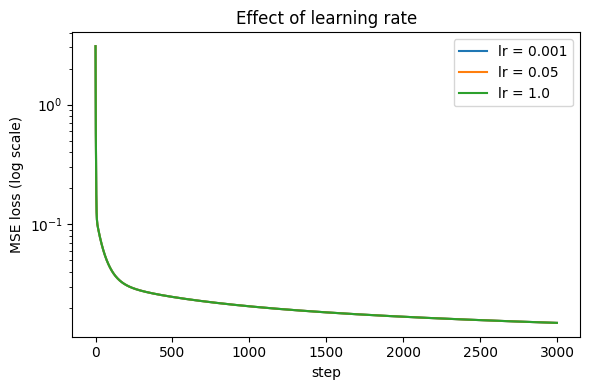

In [ ]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_toy(lr, steps = 3000):
  np.random.seed(RANDOM_STATE)
  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.zeros(8)
  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.zeros(1)

  x_col = x.reshape(-1, 1)   # (100, 1) so matrix multiply works
  y_col = y.reshape(-1, 1)   # (100, 1)

  lr = 0.05
  steps = 3000
  losses = []


  for step in range(steps):
      # ---- forward pass ----
      z1 = x_col @ W1 + b1
      h = np.tanh(z1)                      # No tanh this time
      y_hat = h @ W2 + b2

      loss = np.mean((y_hat - y_col) ** 2)
      losses.append(loss)

      # ---- backward pass ----
      d_yhat = 2 * (y_hat - y_col) / len(y_col)   # (100, 1)
      dW2 = h.T @ d_yhat                           # (8, 1)
      db2 = d_yhat.sum(axis=0)                     # (1,)

      dh = d_yhat @ W2.T                           # (100, 8)
      dz1 = dh * (1 - np.tanh(z1) ** 2)            # No tanh this time
      dW1 = x_col.T @ dz1                          # (1, 8)
      db1 = dz1.sum(axis=0)

      W1 -= lr * dW1
      b1 -= lr * db1
      W2 -= lr * dW2
      b2 -= lr * db2

  return losses


#TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

lrs = [0.001, 0.05, 1.0]
results = {}

for lr in lrs:
  results[lr] = train_toy(lr, steps = 3000)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

plt.figure(figsize = (6, 4))
for lr, losses in results.items():
    plt.plot(losses, label = f"lr = {lr}")
plt.yscale("log")
plt.xlabel("step"); plt.ylabel("MSE loss (log scale)")
plt.title("Effect of learning rate")
plt.legend()
plt.tight_layout()
plt.show()




SECTION 2: A REAL FEEDFORWARD NETWORK IN PYTORCH


Part 2.1 — Preprocess and split (recycled from Lab 2)


In [ ]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

ob = pd.read_csv(OBESITY_URL)
print("Shape: ", ob.shape)
ob.head()
ob.info()
ob.describe()
print("\nMissing values: ", ob.isna().sum().sum())

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
Binary_columns = {'Yes': 0 , 'No': 1}
for col in ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']:
    ob[col] = ob[col].map(Binary_columns)

ob["Gender"] = ob["Gender"].map({"Male": 0, "Female": 1})
ob = pd.get_dummies(ob, columns=["MTRANS","CAEC", "CALC"], drop_first = False)

le = LabelEncoder()
ob['NObeyesdad'] = le.fit_transform(ob['NObeyesdad'])
print('\nClass to int mapping:', dict(zip(le.classes_, le.transform(le.classes_))))


# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = ob.drop(columns=["NObeyesdad"]).values.astype(float)
y = ob['NObeyesdad'].values

# Remove constant columns before splitting to avoid RuntimeWarning from StandardScaler
constant_columns = ob.drop(columns=["NObeyesdad"]).columns[ob.drop(columns=["NObeyesdad"]).std() == 0]
if not constant_columns.empty:
    print(f"Removing constant columns: {list(constant_columns)}")
    X = ob.drop(columns=["NObeyesdad"] + list(constant_columns)).values.astype(float)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.4, random_state= RANDOM_STATE, stratify = y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = RANDOM_STATE, stratify = y_temp
)


# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
# TODO: Fit the scaler on the training set only, then transform train /
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s= scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Val: {X_val.shape[0]}")




# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

def to_tensors(X, y):
    X_t = torch.tensor(X, dtype = torch.float32)
    y_t = torch.tensor(y, dtype = torch.long)
    return X_t, y_t

X_train_t, y_train_t = to_tensors(X_train_s, y_train)
X_val_t, y_val_t = to_tensors(X_val_s, y_val)
X_test_t, y_test_t = to_tensors(X_test_s, y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print("Number of features going into the network:", X_train_s.shape[1])